# Full ACC Pipeline — Local Version (ElevenLabs voice)
Runs on your laptop: real microphone recording, real image upload from disk, the trained road classifier, off-road/damage/traffic-sign detection, speed logic, and a natural ElevenLabs voice for the assistant.

## Requirements before running
- `road_classifier.keras` — your trained model, downloaded from Kaggle's Output tab, placed in the same folder as this notebook
- A Roboflow API key (free account)
- An **ElevenLabs API key** — from your ElevenLabs dashboard (elevenlabs.io) → Profile → API Keys
- A working microphone/speaker

## Data & model sources used in this project
- Road-type training images: [A2D2 Kaggle mirror](https://www.kaggle.com/datasets/testseries1/a2d2-instance-org)
- Extra rural images: [visao/rural-roads on Roboflow Universe](https://universe.roboflow.com/visao/rural-roads)
- Off-road/surface model: [sri-lab/road-surface-classification-lgxl1](https://universe.roboflow.com/sri-lab/road-surface-classification-lgxl1)
- Damage model: [roaddamage-msfnj/road-damage-ww8ex](https://universe.roboflow.com/roaddamage-msfnj/road-damage-ww8ex)
- Traffic sign model: [bhaskrr/traffic-sign-detection-using-yolov11 (GitHub)](https://github.com/bhaskrr/traffic-sign-detection-using-yolov11)

## 1. Install dependencies

In [1]:
!pip install tensorflow roboflow ultralytics openai-whisper elevenlabs google-genai sounddevice scipy pillow matplotlib



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import re
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt

import whisper
from ultralytics import YOLO
from roboflow import Roboflow

from google import genai
from google.genai import types
from elevenlabs.client import ElevenLabs
from elevenlabs import save as save_audio

import sounddevice as sd
from scipy.io.wavfile import write as write_wav

from IPython.display import Audio, display
import tkinter as tk
from tkinter import filedialog


## 3. Config

In [16]:
IMG_SIZE = (224, 224)
CLASS_NAMES = ["autoroute", "urbaine", "rurale"]  # must match the order used during training

LOCAL_MODEL_PATH = "oldroad_classifier.keras"

ROBOFLOW_API_KEY = "gGXHUPHkw6vMLDGV21DF"
ELEVENLABS_API_KEY = "sk_889cfbac51f979d6c8ea2f81c0a0eb4e8846c80b504e1dd9"

# --- Roboflow off-road model ---
OFFROAD_WORKSPACE = "sri-lab"
OFFROAD_PROJECT = "road-surface-classification-lgxl1"
OFFROAD_VERSION = 1
UNPAVED_CLASS_NAMES = {"Unpaved"}
OFFROAD_CONFIDENCE_THRESHOLD = 0.5

# --- Roboflow damage model ---
DAMAGE_WORKSPACE = "roaddamage-msfnj"
DAMAGE_PROJECT = "road-damage-ww8ex"
DAMAGE_VERSION = 1  # UNVERIFIED — confirm on the project's Universe page
DAMAGE_CONFIDENCE_THRESHOLD = 0.5

# --- Traffic sign model (GitHub) ---
SIGN_REPO_URL = "https://github.com/bhaskrr/traffic-sign-detection-using-yolov11.git"
SIGN_REPO_LOCAL_DIR = "traffic_sign_repo"
SIGN_WEIGHTS_FILENAME = "traffic_sign_detector.pt"  # Fixed: real filename in repo
SIGN_CONFIDENCE_THRESHOLD = 0.5
IGNORED_SIGN_CLASSES = {"all"}  # known bogus class from the source dataset export

# --- ElevenLabs voice ---
# Default voice_id below ("George") works fine for French via the multilingual model +
# language_code — but browse elevenlabs.io's Voice Library for one you actually like,
# or run elevenlabs_client.voices.search() to list what's available on your account.
ELEVENLABS_VOICE_ID = "JBFqnCBsd6RMkjVDRZzb"
ELEVENLABS_MODEL_ID = "eleven_multilingual_v2"


# --- Gemini (conversational brain + command understanding) ---
# Free key: aistudio.google.com -> "Get API key" -> create/pick a project -> copy the key
GEMINI_API_KEY = "AQ.Ab8RN6K6V1luqoWXnJlf7L5Wc80uOQhJkBgZ2ysniNnjSLv2jA"
LLM_MODEL = "gemini-1.5-flash"  # Use a valid model name like gemini-1.5-flash or gemini-2.0-flash


## 4. Load the trained road-type classifier

In [17]:
if not os.path.exists(LOCAL_MODEL_PATH):
    raise FileNotFoundError(
        f"{LOCAL_MODEL_PATH} not found. Download it from your Kaggle notebook's Output tab "
        f"and place it next to this notebook."
    )

road_classifier = tf.keras.models.load_model(LOCAL_MODEL_PATH)
print("Road-type classifier loaded.")


Road-type classifier loaded.


## 5. Load the off-road (Roboflow) model

In [18]:
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

offroad_project = rf.workspace(OFFROAD_WORKSPACE).project(OFFROAD_PROJECT)
offroad_model = offroad_project.version(OFFROAD_VERSION).model
print("Off-road model loaded.")


loading Roboflow workspace...
loading Roboflow project...
Off-road model loaded.


In [19]:
def detect_offroad(image_path):
    result = offroad_model.predict(image_path).json()
    predictions = result.get("predictions", [])
    if not predictions:
        return False, 0.0

    top = predictions[0] if isinstance(predictions, list) else predictions
    predicted_class = top.get("class") or top.get("top", "")
    confidence = top.get("confidence", 0.0)

    is_offroad = predicted_class in UNPAVED_CLASS_NAMES and confidence >= OFFROAD_CONFIDENCE_THRESHOLD
    return is_offroad, confidence


## 6. Load the damage (Roboflow) model

In [20]:
damage_project = rf.workspace(DAMAGE_WORKSPACE).project(DAMAGE_PROJECT)
damage_model_rf = damage_project.version(DAMAGE_VERSION).model
print("Damage model loaded.")


loading Roboflow workspace...
loading Roboflow project...
Damage model loaded.


In [21]:
def detect_damage(image_path):
    result = damage_model_rf.predict(image_path, confidence=int(DAMAGE_CONFIDENCE_THRESHOLD * 100), overlap=30).json()
    detections = result.get("predictions", [])
    parsed = [{"class": d.get("class"), "confidence": d.get("confidence", 0.0)} for d in detections]
    max_confidence = max((d["confidence"] for d in parsed), default=0.0)
    is_damaged = len(parsed) > 0
    return is_damaged, max_confidence, parsed


## 7. Load the traffic sign model (GitHub)

In [22]:
if not os.path.exists(SIGN_REPO_LOCAL_DIR):
    os.system(f"git clone {SIGN_REPO_URL} {SIGN_REPO_LOCAL_DIR}")

model_dir = os.path.join(SIGN_REPO_LOCAL_DIR, "model")
print("Files in the model/ folder:")
for f in os.listdir(model_dir):
    print(" ", f)


Files in the model/ folder:
  traffic_sign_detector.pt


In [23]:
sign_weights_path = os.path.join(model_dir, SIGN_WEIGHTS_FILENAME)
print(sign_weights_path)
print(os.path.exists(sign_weights_path))

traffic_sign_repo\model\traffic_sign_detector.pt
True


In [24]:
sign_weights_path = os.path.join(model_dir, SIGN_WEIGHTS_FILENAME)
sign_model = YOLO(sign_weights_path)
print("Traffic sign model loaded. Classes:", sign_model.names)


Traffic sign model loaded. Classes: {0: 'Green Light', 1: 'Red Light', 2: 'Speed Limit 10', 3: 'Speed Limit 100', 4: 'Speed Limit 110', 5: 'Speed Limit 120', 6: 'Speed Limit 20', 7: 'Speed Limit 30', 8: 'Speed Limit 40', 9: 'Speed Limit 50', 10: 'Speed Limit 60', 11: 'Speed Limit 70', 12: 'Speed Limit 80', 13: 'Speed Limit 90', 14: 'Stop'}


In [25]:
def detect_traffic_signs(image_path):
    results = sign_model.predict(image_path, verbose=False)
    detections = []
    for r in results:
        for box in r.boxes:
            conf = float(box.conf[0])
            cls_name = sign_model.names[int(box.cls[0])]
            if cls_name in IGNORED_SIGN_CLASSES or conf < SIGN_CONFIDENCE_THRESHOLD:
                continue
            detections.append({"class": cls_name, "confidence": conf})
    return detections


## 8. Speed logic — road type + damage + sign overrides

In [26]:
BASE_SPEED_BY_ROAD_TYPE = {
    "autoroute": 120,
    "urbaine": 60,
    "rurale": 100,
    "off-road": 70,
}
DAMAGE_SPEED_REDUCTION = 0.30

def get_base_speed(road_type, is_damaged):
    speed = BASE_SPEED_BY_ROAD_TYPE[road_type]
    if is_damaged:
        speed = speed * (1 - DAMAGE_SPEED_REDUCTION)
    return round(speed, 1)


def apply_sign_overrides(current_speed, detected_signs):
    for sign in detected_signs:
        if sign["class"] in ("Stop", "Red Light"):
            return 0, f"{sign['class']} detected — mandatory stop"

    final_speed = current_speed
    override_reason = None
    for sign in detected_signs:
        match = re.search(r"Speed Limit (\d+)", sign["class"])
        if match:
            posted_limit = int(match.group(1))
            if posted_limit < final_speed:
                final_speed = posted_limit
                override_reason = f"Capped to posted limit: {posted_limit} km/h"

    return final_speed, override_reason


## 9. Full combined pipeline

In [27]:
def classify_full(image_path):
    is_offroad, offroad_conf = detect_offroad(image_path)
    if is_offroad:
        road_type = "off-road"
    else:
        img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
        img_array = tf.keras.utils.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0)
        predictions = road_classifier.predict(img_array, verbose=0)
        road_type = CLASS_NAMES[np.argmax(predictions[0])]

    is_damaged, damage_conf, damage_detections = detect_damage(image_path)
    detected_signs = detect_traffic_signs(image_path)

    base_speed = get_base_speed(road_type, is_damaged)
    final_speed, override_reason = apply_sign_overrides(base_speed, detected_signs)

    return {
        "road_type": road_type,
        "damaged": is_damaged,
        "detected_signs": detected_signs,
        "base_speed": base_speed,
        "final_speed_kmh": final_speed,
        "override_reason": override_reason,
    }


## 10. Upload a picture from your laptop and run the full pipeline

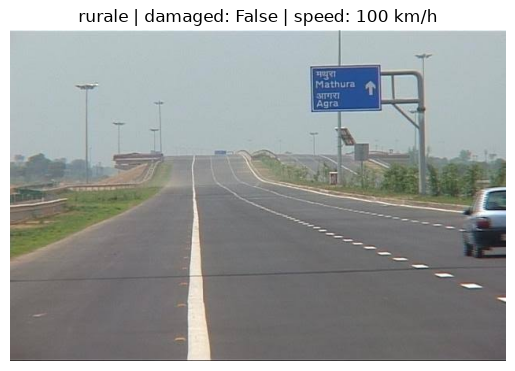

{'road_type': 'rurale', 'damaged': False, 'detected_signs': [], 'base_speed': 100, 'final_speed_kmh': 100, 'override_reason': None}


In [28]:
def pick_image_file():
    root = tk.Tk()
    root.withdraw()
    file_path = filedialog.askopenfilename(
        title="Select a road image",
        filetypes=[("Image files", "*.jpg *.jpeg *.png")]
    )
    root.destroy()
    return file_path


image_path = pick_image_file()

if image_path:
    result = classify_full(image_path)

    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis("off")
    title = f"{result['road_type']} | damaged: {result['damaged']} | speed: {result['final_speed_kmh']} km/h"
    if result["override_reason"]:
        title += f"\n({result['override_reason']})"
    plt.title(title)
    plt.show()

    print(result)
else:
    print("No file selected.")


## 11. Voice assistant — intent parsing, dispatcher, ElevenLabs TTS

In [65]:
whisper_model = whisper.load_model("base")

def transcribe_audio(audio_path):
    """
    No language= argument -> Whisper auto-detects the spoken language.
    Returns (transcript, detected_language_code), e.g. ("hello there", "en").
    """
    try:
        from scipy.io.wavfile import read as read_wav
        sr, audio = read_wav(audio_path)
        if audio.dtype == np.int16:
            audio = audio.astype(np.float32) / 32768.0
        result = whisper_model.transcribe(audio)
        return result["text"].strip(), result["language"]
    except Exception as e:
        print(f"Transcription failed: {e}")
        return "", "en"


# --- Vehicle command tool, now in OpenAI/Groq tool-schema format ---
VEHICLE_TOOL = {
    "type": "function",
    "function": {
        "name": "vehicle_command",
        "description": (
            "Call this when the user gives an instruction that changes something "
            "about the car (window, speed, cruise speed, eco mode, safety distance). "
            "Do NOT call this for questions, greetings, or general conversation."
        ),
        "parameters": {
            "type": "object",
            "properties": {
                "action": {
                    "type": "string",
                    "enum": [
                        "close_window", "open_window",
                        "set_speed_limit", "set_cruise_speed",
                        "enable_eco_mode",
                        "increase_safety_distance", "decrease_safety_distance",
                        "decrease_speed", "increase_speed",
                    ],
                },
                "value": {
                    "type": "integer",
                    "description": "Speed in km/h. Only used for set_speed_limit and set_cruise_speed.",
                },
            },
            "required": ["action"],
        },
    },
}

SYSTEM_PROMPT = """You are the voice assistant embedded in an adaptive cruise control (ADAS) system in a car.

Always reply in the exact same language the user just spoke to you in, whatever language that is.


You have two jobs:
1. If the user gives a command to change something about the car (window, speed limit, cruise speed, eco mode, safety distance, speed up/slow down), call the vehicle_command tool with the right action (and value in km/h if relevant). Along with the tool call, also write one short spoken confirmation sentence in the same language the user spoke.
2. For anything else -- greetings, small talk, "who are you", "what do you do", general questions -- just answer normally and conversationally, like any helpful voice assistant would. Keep replies short (1-3 sentences), since this is spoken out loud in a car, not read on a screen.

Only call the tool for real commands. Never invent vehicle behavior you were not asked for.
"""

from groq import Groq
GROQ_API_KEY = "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"
groq_client = Groq(api_key=GROQ_API_KEY)
LLM_MODEL = "openai/gpt-oss-120b"


def dispatch_command(action, value, vehicle_state):
    if action == "set_speed_limit" and value is not None:
        vehicle_state["speed_limit_kmh"] = value
    elif action == "set_cruise_speed" and value is not None:
        vehicle_state["cruise_speed_kmh"] = value
    elif action == "enable_eco_mode":
        vehicle_state["eco_mode"] = True
    elif action == "increase_safety_distance":
        vehicle_state["safety_distance_level"] += 1
    elif action == "decrease_safety_distance":
        vehicle_state["safety_distance_level"] = max(1, vehicle_state["safety_distance_level"] - 1)
    elif action == "decrease_speed":
        vehicle_state["cruise_speed_kmh"] = max(0, vehicle_state["cruise_speed_kmh"] - 10)
    elif action == "increase_speed":
        vehicle_state["cruise_speed_kmh"] += 10
    elif action == "close_window":
        vehicle_state["window_open"] = False
    elif action == "open_window":
        vehicle_state["window_open"] = True
    return vehicle_state


def understand_and_respond(user_text, vehicle_state):
    """
    Single Groq call that both (a) executes any real vehicle command found in
    user_text, and (b) produces the natural-language reply to speak back,
    in whatever language the user used.
    """
    import json as _json
    try:
        response = groq_client.chat.completions.create(
            model=LLM_MODEL,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": user_text},
            ],
            tools=[VEHICLE_TOOL],
            tool_choice="auto",
        )

        message = response.choices[0].message

        for call in (message.tool_calls or []):
            if call.function.name == "vehicle_command":
                args = _json.loads(call.function.arguments)
                action = args.get("action")
                value = args.get("value")
                vehicle_state = dispatch_command(action, value, vehicle_state)

        spoken_text = (message.content or "").strip()
        if not spoken_text:
            spoken_text = "Done."  # fallback if the model only returned a tool call, no text

        return spoken_text, vehicle_state
    except Exception as e:
        print(f"Groq failed: {e}")
        return "I am having trouble connecting to my brain right now.", vehicle_state


elevenlabs_client = ElevenLabs(api_key=ELEVENLABS_API_KEY)

def speak(text, output_path="response.mp3", voice_id=ELEVENLABS_VOICE_ID, language_code="en"):
    try:
        audio = elevenlabs_client.text_to_speech.convert(
            text=text,
            voice_id=voice_id,
            model_id=ELEVENLABS_MODEL_ID,
            language_code=language_code,
            output_format="mp3_44100_128",
        )
        save_audio(audio, output_path)
        return output_path
    except Exception as e:
        print(f"ElevenLabs TTS failed: {e}")
        return None

## 12. Record your own voice with your laptop's microphone

In [66]:
def record_audio(duration=5, samplerate=16000, output_path="mic_recording.wav"):
    try:
        print(f"Recording for {duration} seconds -- speak now, any language...")
        recording = sd.rec(int(duration * samplerate), samplerate=samplerate, channels=1, dtype='int16')
        sd.wait()
        write_wav(output_path, samplerate, recording)
        print(f"Recording saved to {output_path}")
        return output_path
    except Exception as e:
        print(f"Recording failed: {e}")
        return None


vehicle_state = {
    "cruise_speed_kmh": 50,
    "speed_limit_kmh": None,
    "eco_mode": False,
    "safety_distance_level": 2,
    "window_open": True,
}

audio_path = record_audio(duration=5)

if audio_path:
    text, detected_language = transcribe_audio(audio_path)
    print(f"\nWhisper heard ({detected_language}): {text!r}")

    if text:
        response_text, vehicle_state = understand_and_respond(text, vehicle_state)
        print(f"Response: {response_text}")

        response_audio = speak(response_text, language_code=detected_language)
        if response_audio:
            display(Audio(response_audio, autoplay=True))

    print("\nUpdated vehicle state:", vehicle_state)


Recording for 5 seconds -- speak now, any language...
Recording saved to mic_recording.wav

Whisper heard (en): 'Hello there, who are you?'
Response: I'm the voice assistant embedded in your car's adaptive cruise control system, here to help you with any questions or commands you might have while driving. How can I assist you today?



Updated vehicle state: {'cruise_speed_kmh': 50, 'speed_limit_kmh': None, 'eco_mode': False, 'safety_distance_level': 2, 'window_open': True}


## 13. Speed-change announcements (tie the image pipeline to the voice assistant)

In [53]:
SPEED_SUGGESTION_TEMPLATES = {
    "autoroute": "Autoroute détectée. Vitesse suggérée : {speed} kilomètres heure.",
    "urbaine":   "Zone urbaine détectée. Vitesse suggérée : {speed} kilomètres heure.",
    "rurale":    "Route rurale détectée. Vitesse suggérée : {speed} kilomètres heure.",
    "off-road":  "Terrain hors route détecté. Vitesse suggérée : {speed} kilomètres heure.",
}

_last_announced_speed = {"value": None}

def announce_speed_suggestion(road_type, suggested_speed, override_reason=None):
    if suggested_speed == _last_announced_speed["value"]:
        return None

    _last_announced_speed["value"] = suggested_speed

    if override_reason:
        text = f"{override_reason}. Vitesse suggérée : {suggested_speed} kilomètres heure."
    else:
        template = SPEED_SUGGESTION_TEMPLATES.get(road_type, "Vitesse suggérée : {speed} kilomètres heure.")
        text = template.format(speed=suggested_speed)

    audio_path = speak(text, output_path="speed_announcement.mp3")
    return text, audio_path


if "result" in dir():
    announcement = announce_speed_suggestion(result["road_type"], result["final_speed_kmh"], result["override_reason"])
    if announcement:
        text, audio_path = announcement
        print(f"Assistant says: {text}")
        display(Audio(audio_path, autoplay=True))
    else:
        print("Assistant stays silent (speed unchanged)")


Assistant says: Route rurale détectée. Vitesse suggérée : 100 kilomètres heure.
